In [27]:
import pandas as pd

df = pd.read_csv("../../full_prompt_test/summary_v2.csv")

df

,model_name,prompt_name,BLEU,ROUGE-L,JSD,Jaccard,Levenshtein,BERTScore
0,m0,p1,2.145182e-03,0.033002,0.173343,0.006891,0.121528,0.346648
1,m0,p2,1.194758e-02,0.131654,0.219093,0.064181,0.206554,0.409109
2,m0,p3,4.071299e-03,0.054839,0.181849,0.017856,0.122538,0.357743
3,m0,p4,3.260888e-03,0.114448,0.186219,0.040844,0.195440,0.406438
4,m0,p5,1.194673e-02,0.099249,0.192853,0.032788,0.156877,0.379599
5,m0,icl_p6,3.881836e-02,0.259641,0.341723,0.210778,0.366755,0.590706
6,m0,icl_p7,2.755927e-02,0.167850,0.270842,0.124073,0.237505,0.477093
7,m0,icl_p8,3.450583e-02,0.222652,0.309344,0.199068,0.304982,0.558643
8,m2,p1,4.584589e-03,0.071787,0.179728,0.017485,0.156158,0.371088
9,m2,p2,7.569068e-03,0.113135,0.205736,0.044408,0.186443,0.403013


In [28]:
prompt_name_map = {
    "icl_p6": "p6",
    "icl_p7": "p7",
    "icl_p8": "p8",
}

df["prompt_name"] = df["prompt_name"].replace(prompt_name_map)

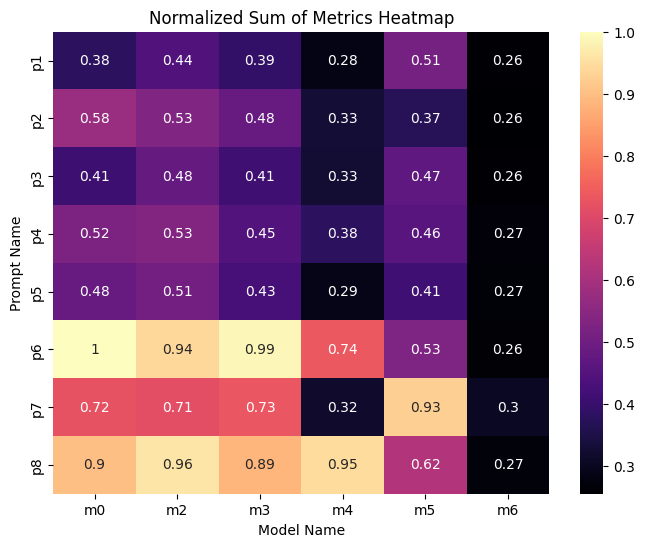

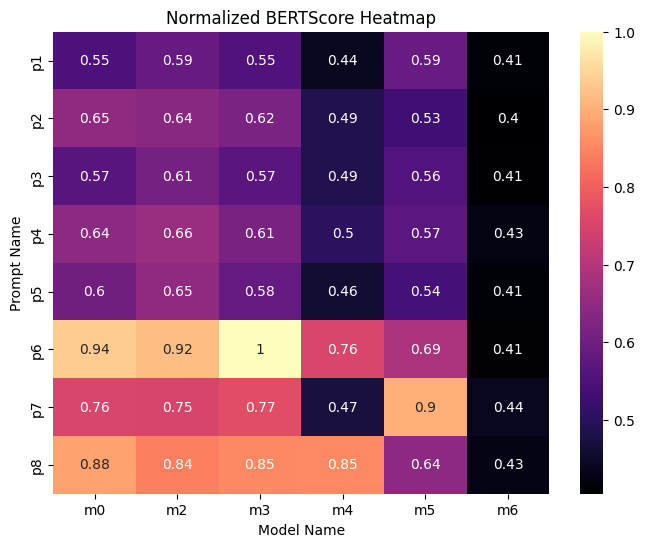

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your loaded dataframe
# Sum of all metric columns (excluding model_name and prompt_name)
metric_cols = ['BLEU', 'ROUGE-L', 'JSD', 'Jaccard', 'Levenshtein', 'BERTScore']
df['sum_metrics'] = df[metric_cols].sum(axis=1)

# --- 1️⃣ Heatmap for sum of metrics ---
sum_pivot = df.pivot(index='prompt_name', columns='model_name', values='sum_metrics')
# Normalize to 0–1 by dividing by the max
sum_pivot_norm = sum_pivot / sum_pivot.max().max()

plt.figure(figsize=(8, 6))
sns.heatmap(sum_pivot_norm, annot=True, cmap='magma')
plt.title("Normalized Sum of Metrics Heatmap")
plt.xlabel("Model Name")
plt.ylabel("Prompt Name")
plt.show()

# --- 2️⃣ Heatmap for BERTScore ---
bert_pivot = df.pivot(index='prompt_name', columns='model_name', values='BERTScore')
# Normalize to 0–1 by dividing by the max
bert_pivot_norm = bert_pivot / bert_pivot.max().max()

plt.figure(figsize=(8, 6))
sns.heatmap(bert_pivot_norm, annot=True, cmap='magma')
plt.title("Normalized BERTScore Heatmap")
plt.xlabel("Model Name")
plt.ylabel("Prompt Name")
plt.show()


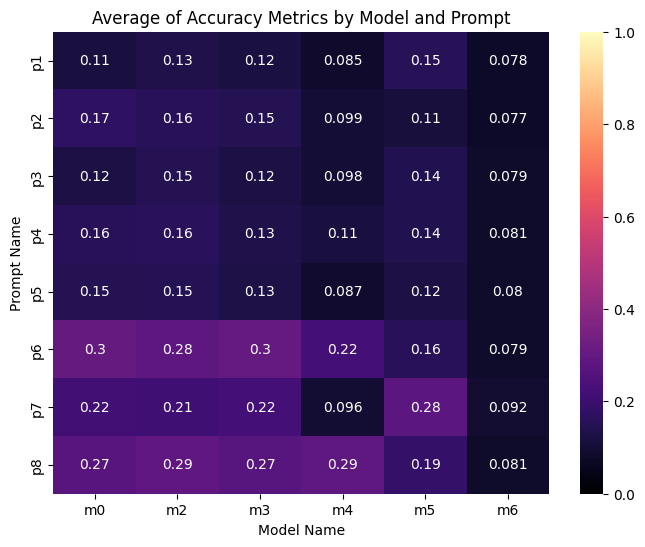

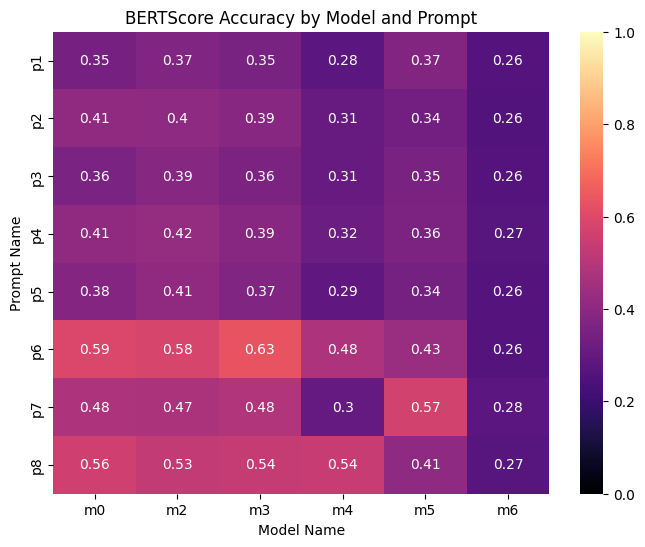

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is already loaded
metric_cols = ['BLEU', 'ROUGE-L', 'JSD', 'Jaccard', 'Levenshtein', 'BERTScore']
df['avg_metrics'] = df[metric_cols].mean(axis=1)

# --- 1️⃣ Heatmap for sum of metrics ---
avg_pivot = df.pivot(index='prompt_name', columns='model_name', values='avg_metrics')

plt.figure(figsize=(8, 6))
sns.heatmap(avg_pivot, annot=True, cmap='magma', vmin=0, vmax=1)
plt.title("Average of Accuracy Metrics by Model and Prompt")
plt.xlabel("Model Name")
plt.ylabel("Prompt Name")
plt.show()

# --- 2️⃣ Heatmap for BERTScore ---
bert_pivot = df.pivot(index='prompt_name', columns='model_name', values='BERTScore')

plt.figure(figsize=(8, 6))
sns.heatmap(bert_pivot, annot=True, cmap='magma', vmin=0, vmax=1)
plt.title("BERTScore Accuracy by Model and Prompt")
plt.xlabel("Model Name")
plt.ylabel("Prompt Name")
plt.show()
